In [2]:
import pandas as pd

df = pd.read_csv("Battery_RUL.csv")

print(df.shape)
print(df.columns)
print(df.head())
print(df.describe())

(15064, 9)
Index(['Cycle_Index', 'Discharge Time (s)', 'Decrement 3.6-3.4V (s)',
       'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)',
       'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)',
       'RUL'],
      dtype='object')
   Cycle_Index  Discharge Time (s)  Decrement 3.6-3.4V (s)  \
0          1.0             2595.30             1151.488500   
1          2.0             7408.64             1172.512500   
2          3.0             7393.76             1112.992000   
3          4.0             7385.50             1080.320667   
4          6.0            65022.75            29813.487000   

   Max. Voltage Dischar. (V)  Min. Voltage Charg. (V)  Time at 4.15V (s)  \
0                      3.670                    3.211           5460.001   
1                      4.246                    3.220           5508.992   
2                      4.249                    3.224           5508.993   
3                      4.250                    3.225           

In [5]:
!pip install xgboost
!pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-macosx_12_0_arm64.whl (8.7 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-learn] [scikit-learn]


## XGBoost

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

from xgboost import XGBRegressor

In [7]:
df = pd.read_csv("Battery_RUL.csv")
print(df.shape)
print(df.columns)
df.head()

(15064, 9)
Index(['Cycle_Index', 'Discharge Time (s)', 'Decrement 3.6-3.4V (s)',
       'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)',
       'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)',
       'RUL'],
      dtype='object')


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107


In [8]:
print(df.isnull().sum())
df.describe()

Cycle_Index                  0
Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
dtype: int64


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
count,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000
mean,556.155005,4581.273960,1239.784672,3.908176,3.577904,3768.336171,5461.266970,10066.496204,554.194172
std,322.378480,33144.012077,15039.589269,0.091003,0.123695,9129.552477,25155.845202,26415.354121,322.434514
min,1.000000,8.690000,-397645.908000,3.043000,3.022000,-113.584000,5.980000,5.980000,0.000000
25%,271.000000,1169.310000,319.600000,3.846000,3.488000,1828.884179,2564.310000,7841.922500,277.000000
50%,560.000000,1557.250000,439.239471,3.906000,3.574000,2930.203500,3824.260000,8320.415000,551.000000
75%,833.000000,1908.000000,600.000000,3.972000,3.663000,4088.326500,5012.350000,8763.282500,839.000000
max,1134.000000,958320.370000,406703.768000,4.363000,4.379000,245101.117000,880728.100000,880728.100000,1133.000000


In [9]:
df_clean = df.copy()

time_like_cols = [
    "Discharge Time (s)",
    "Decrement 3.6-3.4V (s)",
    "Time at 4.15V (s)",
    "Time constant current (s)",
    "Charging time (s)"
]

for col in time_like_cols:
    df_clean = df_clean[df_clean[col] > 0]

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (15064, 9)
Cleaned shape: (15031, 9)


In [10]:
df_clean.describe()

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
count,15031.000000,15031.000000,15031.000000,15031.000000,15031.000000,15031.000000,15031.000000,15031.000000,15031.000000
mean,556.501563,4265.676749,1442.170625,3.907649,3.577959,3679.402558,5321.700476,9934.158147,553.849045
std,322.415253,31899.898072,13793.943027,0.090082,0.122206,8818.901831,24547.558775,25864.035804,322.470885
min,1.000000,8.690000,31.168831,3.043000,3.022000,14.052000,5.980000,5.980000,0.000000
25%,271.000000,1168.780000,320.000000,3.846000,3.489000,1828.884429,2564.310000,7842.095000,277.000000
50%,560.000000,1555.940000,439.285714,3.906000,3.574000,2924.359000,3824.250000,8319.690000,550.000000
75%,834.000000,1908.000000,600.000000,3.971000,3.663000,4082.375000,5012.350000,8760.220000,839.000000
max,1134.000000,958320.370000,406703.768000,4.363000,4.300000,245101.117000,880728.100000,880728.100000,1133.000000


In [25]:
feature_cols = [
    "Discharge Time (s)",
    "Decrement 3.6-3.4V (s)",
    "Max. Voltage Dischar. (V)",
    "Min. Voltage Charg. (V)",
    "Time at 4.15V (s)",
    "Time constant current (s)",
    "Charging time (s)"
]

target_col = "RUL"

X = df_clean[feature_cols]
y = df_clean[target_col]

print(X.shape, y.shape)

(15031, 7) (15031,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (12024, 7) (12024,)
Test shape: (3007, 7) (3007,)


In [27]:
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

In [28]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train_imp, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [29]:
y_pred = xgb_model.predict(X_test_imp)

print("First 10 predictions:", y_pred[:10])
print("First 10 true values:", y_test.values[:10])

First 10 predictions: [ 114.40588 1007.76117 1068.3296   300.9467   872.954    107.61962
  142.19765  223.65779  800.50507  649.35736]
First 10 true values: [ 130 1007 1079  355  865  108  147  255  785  654]


In [30]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")

MAE:  17.0602
RMSE: 25.3716
R^2:  0.9938


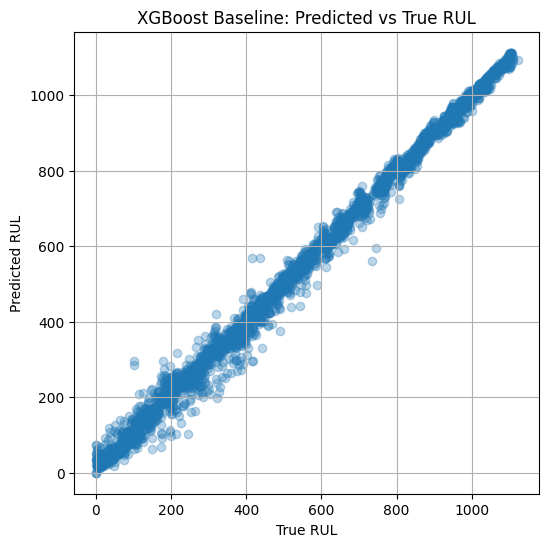

In [31]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost Baseline: Predicted vs True RUL")
plt.grid(True)
plt.show()

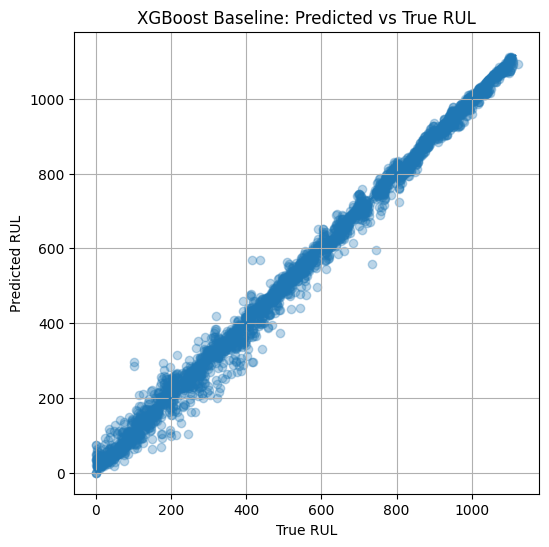

In [32]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost Baseline: Predicted vs True RUL")
plt.grid(True)
plt.show()

In [33]:
importances = xgb_model.feature_importances_

feat_imp_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feat_imp_df

,Feature,Importance
0,Discharge Time (s),0.445006
4,Time at 4.15V (s),0.247981
5,Time constant current (s),0.182574
1,Decrement 3.6-3.4V (s),0.098556
2,Max. Voltage Dischar. (V),0.014689
3,Min. Voltage Charg. (V),0.005899
6,Charging time (s),0.005296


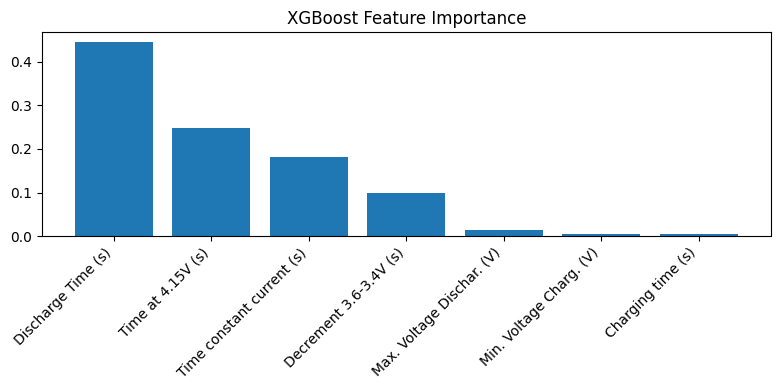

In [34]:
plt.figure(figsize=(8, 4))
plt.bar(feat_imp_df["Feature"], feat_imp_df["Importance"])
plt.xticks(rotation=45, ha="right")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [35]:
results_df = pd.DataFrame({
    "Model": ["XGBoost (with Cycle_Index)"],
    "MAE": [mae],
    "RMSE": [rmse]
})

results_df

,Model,MAE,RMSE
0,XGBoost (with Cycle_Index),17.060184,25.371583


## CNN (1D Convolutional) — Combined Dataset

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

df_combined = pd.read_csv("combined_scaled_battery_data.csv")

feature_cols = [
    "Discharge Time (s)",
    "Decrement 3.6-3.4V (s)",
    "Max. Voltage Dischar. (V)",
    "Min. Voltage Charg. (V)",
    "Time at 4.15V (s)",
    "Time constant current (s)",
    "Charging time (s)",
]

print("Combined dataset shape:", df_combined.shape)
print("Is_NASA counts:", df_combined["Is_NASA"].value_counts().to_dict())

In [ ]:
WINDOW_SIZE = 30

def split_into_battery_segments(dataframe):
    """Split dataframe into per-battery segments by detecting RUL resets."""
    rul_values = dataframe["RUL"].values
    rul_diffs = np.diff(rul_values)
    boundary_indices = np.where(rul_diffs > 0)[0] + 1

    segment_starts = np.concatenate([[0], boundary_indices])
    segment_ends = np.concatenate([boundary_indices, [len(dataframe)]])

    segments = []
    for start, end in zip(segment_starts, segment_ends):
        segments.append(dataframe.iloc[start:end].reset_index(drop=True))
    return segments


def build_sliding_windows(segments, window_size):
    """Create (window, rul_label) pairs from each battery segment."""
    windows = []
    labels = []
    for seg in segments:
        feature_array = seg[feature_cols].values.astype(np.float32)
        rul_array = seg["RUL"].values.astype(np.float32)
        num_windows = len(seg) - window_size
        for i in range(num_windows):
            windows.append(feature_array[i : i + window_size])
            labels.append(rul_array[i + window_size - 1])
    return np.array(windows), np.array(labels, dtype=np.float32)


battery_segments = split_into_battery_segments(df_combined)
print(f"Number of batteries: {len(battery_segments)}")
print(f"Segment lengths (first 5): {[len(s) for s in battery_segments[:5]]}")

X_windows, y_rul = build_sliding_windows(battery_segments, WINDOW_SIZE)
print(f"Windows shape: {X_windows.shape}")   # (N, window_size, num_features)
print(f"Labels shape:  {y_rul.shape}")

In [ ]:
# Battery-aware train/test split: hold out last N batteries as test set
NUM_TEST_BATTERIES = 8

train_segments = battery_segments[:-NUM_TEST_BATTERIES]
test_segments  = battery_segments[-NUM_TEST_BATTERIES:]

X_train_win, y_train_rul = build_sliding_windows(train_segments, WINDOW_SIZE)
X_test_win,  y_test_rul  = build_sliding_windows(test_segments,  WINDOW_SIZE)

print(f"Train windows: {X_train_win.shape}, labels: {y_train_rul.shape}")
print(f"Test  windows: {X_test_win.shape},  labels: {y_test_rul.shape}")

In [ ]:
class BatteryWindowDataset(Dataset):
    def __init__(self, windows, labels):
        # windows: (N, window_size, num_features) -> transpose to (N, num_features, window_size) for Conv1d
        self.X = torch.tensor(windows).permute(0, 2, 1)
        self.y = torch.tensor(labels).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = BatteryWindowDataset(X_train_win, y_train_rul)
test_dataset  = BatteryWindowDataset(X_test_win,  y_test_rul)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")
sample_x, sample_y = next(iter(train_loader))
print(f"Batch X shape: {sample_x.shape}  (batch, num_features, window_size)")
print(f"Batch y shape: {sample_y.shape}")

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size // 2)
        self.bn   = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class RULConvNet(nn.Module):
    """1D CNN for battery RUL regression.

    Input:  (batch, num_features, window_size)
    Output: (batch, 1)
    """

    def __init__(self, num_features: int, window_size: int):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(num_features, 64,  kernel_size=3),
            ConvBlock(64,           128, kernel_size=3),
            nn.MaxPool1d(kernel_size=2),
            ConvBlock(128,          128, kernel_size=3),
            ConvBlock(128,          64,  kernel_size=3),
        )
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        features = self.encoder(x)
        pooled   = self.global_avg_pool(features)
        return self.regressor(pooled)


NUM_FEATURES = len(feature_cols)
model = RULConvNet(num_features=NUM_FEATURES, window_size=WINDOW_SIZE)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

In [ ]:
DEVICE     = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
NUM_EPOCHS = 50
LR         = 1e-3

model     = RULConvNet(num_features=NUM_FEATURES, window_size=WINDOW_SIZE).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f"Training on: {DEVICE}")

train_losses = []
val_losses   = []

for epoch in range(1, NUM_EPOCHS + 1):
    # --- train ---
    model.train()
    epoch_train_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * len(batch_y)
    epoch_train_loss /= len(train_dataset)

    # --- validate ---
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
            predictions = model(batch_x)
            epoch_val_loss += criterion(predictions, batch_y).item() * len(batch_y)
    epoch_val_loss /= len(test_dataset)

    scheduler.step()
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS}  train_loss={epoch_train_loss:.2f}  val_loss={epoch_val_loss:.2f}")

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train MSE Loss")
plt.plot(val_losses,   label="Val   MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("CNN Training Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(DEVICE)
        preds   = model(batch_x).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(batch_y.numpy())

cnn_preds  = np.concatenate(all_preds).flatten()
cnn_labels = np.concatenate(all_labels).flatten()

cnn_mae  = mean_absolute_error(cnn_labels, cnn_preds)
cnn_rmse = np.sqrt(mean_squared_error(cnn_labels, cnn_preds))
cnn_r2   = r2_score(cnn_labels, cnn_preds)

print(f"CNN  MAE:  {cnn_mae:.4f}")
print(f"CNN  RMSE: {cnn_rmse:.4f}")
print(f"CNN  R^2:  {cnn_r2:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs true scatter
axes[0].scatter(cnn_labels, cnn_preds, alpha=0.3, s=10)
min_val = min(cnn_labels.min(), cnn_preds.min())
max_val = max(cnn_labels.max(), cnn_preds.max())
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red")
axes[0].set_xlabel("True RUL")
axes[0].set_ylabel("Predicted RUL")
axes[0].set_title("CNN: Predicted vs True RUL")
axes[0].grid(True)

# Residuals
residuals = cnn_preds - cnn_labels
axes[1].hist(residuals, bins=50, edgecolor="black")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (Predicted - True)")
axes[1].set_ylabel("Count")
axes[1].set_title("CNN: Residual Distribution")
axes[1].grid(True)

plt.tight_layout()
plt.show()